Importations et chargement

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords

# Chargement
df = pd.read_csv('../data/dataset.csv')

# Aperçu
print(f"Format du dataset : {df.shape}")
df.head()

Format du dataset : (20000, 15)


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


Distribution des types 

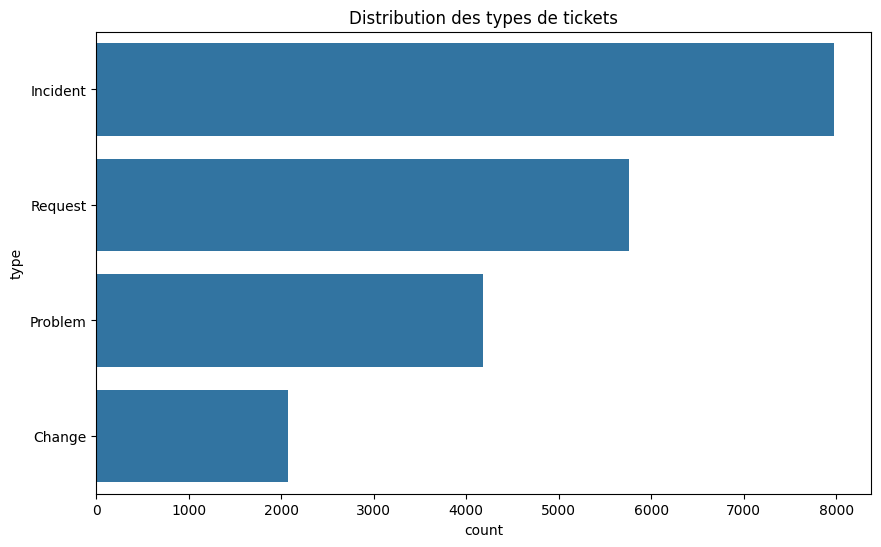

In [2]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='type', order=df['type'].value_counts().index)
plt.title('Distribution des types de tickets')
plt.show()

Fusion et Longueur des emails

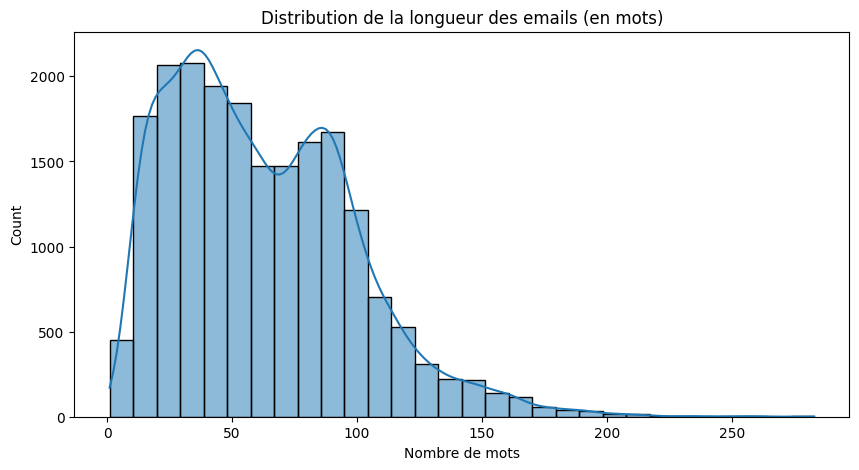

In [3]:
# Fusion
df['full_text'] = df['subject'].fillna('') + " " + df['body'].fillna('')

# Calcul de la longueur (nombre de mots)
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))

# Visualisation
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title('Distribution de la longueur des emails (en mots)')
plt.xlabel('Nombre de mots')
plt.show()

Le sujet contient souvent l'intention principale  et le corps contient les détails techniques. Fusionner les deux permet au modèle d'avoir tout le contexte dans un seul vecteur d'embedding.

L'histogramme des longueurs m'a permis de voir s'il y avait des emails vides ou anormalement longs qui pourraient fausser les embeddings.

Test du Nettoyage NLP

In [4]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english') + stopwords.words('german'))

def preview_clean(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    return [w for w in words if w not in stop_words]

# Test sur le premier ticket
sample_text = df['full_text'].iloc[0]
print("Texte Original :", sample_text[:150], "...")
print("\nAprès Nettoyage :", preview_clean(sample_text)[:20], "...")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayoub\AppData\Roaming\nltk_data...


Texte Original : Unvorhergesehener Absturz der Datenanalyse-Plattform Die Datenanalyse-Plattform brach unerwartet ab, da die Speicheroberfläche zu gering war. Ich habe ...

Après Nettoyage : ['unvorhergesehener', 'absturz', 'datenanalyseplattform', 'datenanalyseplattform', 'brach', 'unerwartet', 'ab', 'speicheroberfläche', 'gering', 'versucht', 'laravel', '8', 'macbook', 'pro', 'neu', 'starten', 'problem', 'behält', 'benötige', 'unterstützung'] ...


[nltk_data]   Unzipping corpora\stopwords.zip.


Le dataset est bilingue. Si on ne supprime que les mots anglais, les mots allemands comme 'und' ou 'ich' vont polluer les données et fausser la classification car ils apparaîtront partout sans apporter de sens technique.

L'ordinateur ne lit pas des phrases, il traite des unités de sens (tokens). La tokenisation permet de passer d'un bloc de texte brut à une liste de mots que l'on peut filtrer